# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Проверка гипотезы о пользовательской активности в сервисе Яндекс Книги

- Автор: Ирина Лаптева
- Дата: 4 марта 2026

## Цели проекта

Проверить гипотезу о различиях в пользовательском поведении между пользователями из Москвы и Санкт-Петербурга в сервисе Яндекс Книги. Ранее проведённый анализ показал, что средний LTV пользователей из Санкт-Петербурга выше, чем у пользователей из Москвы. В рамках проекта необходимо проверить предположение о том, что более высокий LTV может быть связан с более высокой вовлечённостью пользователей, выраженной в количестве времени, проведённого за чтением и прослушиванием контента в приложении.

## Задачи проекта

- Подготовить данные для анализа: загрузить датасет, содержащий информацию о пользователях из Москвы и Санкт-Петербурга и их суммарном времени активности в приложении.

- Провести первичный исследовательский анализ данных: проверить структуру датасета, наличие пропусков и дубликатов, а также изучить основные статистические характеристики выборок.

- Сравнить распределения времени активности пользователей в двух городах и оценить различия между ними.

- Сформулировать статистические гипотезы о различии среднего времени использования сервиса между пользователями Москвы и Санкт-Петербурга.

- Провести статистический тест для проверки гипотезы и определить, является ли наблюдаемая разница статистически значимой.

- Интерпретировать полученные результаты и сформулировать вывод о подтверждении или опровержении гипотезы.

## Описание данных

Для проверки гипотезы используются данные об активности пользователей сервиса Яндекс Книги. Данные были предварительно подготовлены с помощью SQL и содержат информацию о пользователях из двух городов, Москвы и Санкт-Петербурга, и их суммарной активности в приложении.

Набор данных включает агрегированную информацию о времени, которое пользователи провели за чтением и прослушиванием книг в приложении. Период наблюдений охватывает интервал с 1 сентября по 11 декабря 2024 года.

В датасете представлены следующие поля:

- city — город пользователя (Москва или Санкт-Петербург);

- puid — уникальный идентификатор пользователя;

- hours — суммарное количество часов, которое пользователь провёл за чтением и прослушиванием контента в приложении за рассматриваемый период.

Каждая строка в датасете соответствует одному пользователю и содержит информацию о его городе и общем времени активности в сервисе. Эти данные используются для сравнения пользовательской активности между двумя группами и последующей статистической проверки гипотезы.

## Содержимое проекта

- Загрузка данных и знакомство с ними
- Сравнительный анализ групп пользователей
- Проверка гипотезы в Python
- Аналитическая записка
---

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)

In [3]:
# посмотрим первые строки
df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
# общая информация о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


Датасет содержит 8784 записи и 4 столбца. Пропущенных значений в данных нет. Переменная city имеет строковый тип и содержит информацию о городе пользователя, puid — уникальный идентификатор пользователя, hours — суммарное количество часов активности пользователя. Столбец Unnamed: 0 представляет собой технический индекс, который можно не использовать в дальнейшем анализе.

In [5]:
# базовые статистики
df.describe()

,puid,hours
count,8.784000e+03,8784.000000
mean,1.029234e+13,11.087670
std,1.073532e+14,37.701350
min,9.668000e+03,0.000018
25%,3.239271e+08,0.066246
50%,8.828218e+08,0.942344
75%,1.516464e+09,6.065151
max,1.130000e+15,978.764775


По данным описательной статистики видно, что среднее значение активности пользователей составляет около 11,09 часов, однако медиана значительно ниже — 0,94 часа, что указывает на сильную асимметрию распределения. Большинство пользователей проводит в приложении относительно немного времени, тогда как небольшая часть пользователей демонстрирует очень высокую активность. Это подтверждается большим стандартным отклонением (37,7 часа) и максимальным значением 978,76 часа.

In [6]:
# количество дубликатов по puid
df['puid'].duplicated().sum()

244

In [7]:
# вывод строк с дублирующимися puid
df[df['puid'].duplicated(keep=False)]

,city,puid,hours
35,Москва,2637041,10.317371
134,Москва,9979490,32.415573
145,Москва,10597984,42.931506
150,Москва,10815097,9.086655
187,Москва,13626259,21.104167
...,...,...,...
8771,Санкт-Петербург,1130000018516717,0.517778
8772,Санкт-Петербург,1130000018954257,33.583294
8773,Санкт-Петербург,1130000020425037,2.386944
8775,Санкт-Петербург,1130000023864516,14.384722


Проверка показала наличие 244 дубликатов по идентификатору пользователя puid. При выводе строк с повторяющимися идентификаторами было обнаружено 488 записей, так как каждый дубликат представлен как минимум двумя строками. Это означает, что некоторые пользователи встречаются в датасете более одного раза. Для дальнейшего анализа необходимо учитывать только уникальные идентификаторы пользователей, чтобы один пользователь не влиял на результаты исследования несколько раз.

In [8]:
df = df.drop_duplicates(subset='puid')

В данных были обнаружены дубликаты по идентификатору пользователя puid. Поскольку каждая строка должна соответствовать одному пользователю, дубликаты были удалены. Это позволяет избежать повторного учёта одних и тех же пользователей и обеспечивает корректность последующего статистического анализа.

## Сравнительный анализ групп пользователей

Перед проверкой статистической гипотезы необходимо провести предварительный анализ данных. На этом этапе сравниваются размеры групп пользователей из разных городов, а также их основные статистические характеристики и распределение времени активности. Это позволяет лучше понять структуру данных и убедиться, что выборки корректны для дальнейшего статистического анализа.

In [9]:
# описательная статистика по городам
df.groupby('city')['hours'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,6234.0,10.881092,36.851683,0.000018,0.059903,0.924498,5.939972,857.209373
Санкт-Петербург,2306.0,11.264433,39.831755,0.000025,0.060173,0.875355,6.138424,978.764775


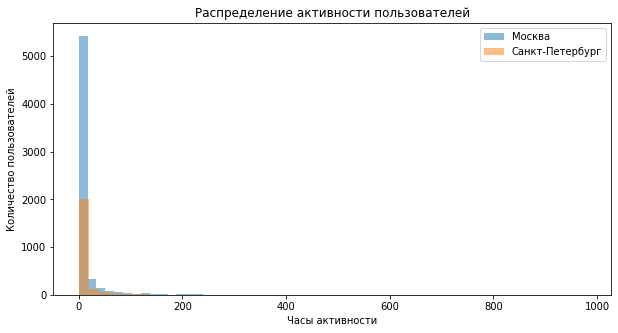

In [10]:
plt.figure(figsize=(10,5))

for city in df['city'].unique():
    plt.hist(df[df['city'] == city]['hours'], bins=50, alpha=0.5, label=city)

plt.xlabel('Часы активности')
plt.ylabel('Количество пользователей')
plt.title('Распределение активности пользователей')
plt.legend()
plt.show()

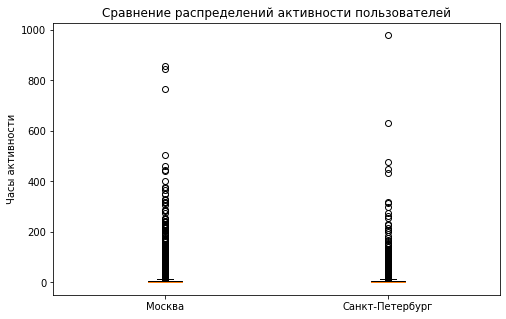

In [11]:
plt.figure(figsize=(8,5))
plt.boxplot(
    [df[df['city']=='Москва']['hours'],
     df[df['city']=='Санкт-Петербург']['hours']],
    labels=['Москва','Санкт-Петербург']
)

plt.ylabel('Часы активности')
plt.title('Сравнение распределений активности пользователей')
plt.show()

Размеры групп пользователей различаются: в выборке 6234 пользователя из Москвы и 2306 пользователей из Санкт-Петербурга. Среднее время активности пользователей в Санкт-Петербурге немного выше (11.26 часа) по сравнению с Москвой (10.88 часа), однако медианные значения в обеих группах близки (около 0.9 часа). 

Распределения активности в обеих группах сильно асимметричны и содержат значительное количество выбросов: большинство пользователей проводит в приложении немного времени, тогда как небольшая часть пользователей демонстрирует очень высокую активность. 

Визуальный анализ показывает, что распределения групп похожи, поэтому для проверки различий в среднем времени активности необходимо провести статистический тест.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [12]:
# разделяем данные на две выборки по городам
moscow = df[df['city'] == 'Москва']['hours']
spb = df[df['city'] == 'Санкт-Петербург']['hours']

# посмотрим среднее значение активности в каждой группе
print('Среднее время активности пользователей:')
print('Москва:', moscow.mean())
print('Санкт-Петербург:', spb.mean())

Среднее время активности пользователей:
Москва: 10.88109206345796
Санкт-Петербург: 11.264433367029522


In [13]:
# проводим t-тест для двух независимых выборок
t_stat, p_value = stats.ttest_ind(spb, moscow, alternative='greater')

print('\nРезультаты t-теста:')
print('t-статистика:', t_stat)
print('p-value:', p_value)


Результаты t-теста:
t-статистика: 0.4174122942907679
p-value: 0.338193679651558


In [14]:
# задаем уровень статистической значимости
alpha = 0.05

# проверяем гипотезу
if p_value < alpha:
    print('\nОтвергаем нулевую гипотезу: средняя активность пользователей из Санкт-Петербурга статистически выше.')
else:
    print('\nНет оснований отвергнуть нулевую гипотезу: статистически значимых различий не обнаружено.')


Нет оснований отвергнуть нулевую гипотезу: статистически значимых различий не обнаружено.


## 3. Аналитическая записка

Для проверки гипотезы был использован t-тест для двух независимых выборок. Уровень статистической значимости принят равным α = 0.05. Проверка проводилась как односторонний тест, поскольку альтернативная гипотеза предполагала, что средняя активность пользователей из Санкт-Петербурга выше, чем у пользователей из Москвы.

По результатам теста было получено p-value = 0.338. Поскольку значение p-value оказалось больше уровня значимости (0.05), нет оснований отвергнуть нулевую гипотезу. Это означает, что статистически значимых различий в среднем времени активности пользователей из Москвы и Санкт-Петербурга обнаружено не было.

Дополнительный анализ данных показывает, что средние значения активности пользователей в двух городах действительно близки: 10.88 часов для Москвы и 11.26 часов для Санкт-Петербурга. При этом медианные значения в обеих группах составляют около 0.9 часа, что указывает на сильную асимметрию распределения. Большинство пользователей проводит в приложении относительно небольшое количество времени, тогда как небольшая доля пользователей демонстрирует очень высокую активность.

Также наблюдается высокая вариативность данных: стандартное отклонение превышает 36–39 часов, а максимальные значения активности достигают 857 часов в Москве и 978 часов в Санкт-Петербурге. Наличие таких экстремальных значений (выбросов) существенно увеличивает разброс данных и может снижать чувствительность статистического теста к небольшим различиям между группами.

Одной из возможных причин полученного результата может быть то, что различие в активности пользователей между городами действительно невелико и не оказывает существенного влияния на среднее значение показателя.

----

# Часть 2. Анализ результатов A/B-тестирования

## 1. Цели исследования.



Цель исследования — оценить результаты A/B-тестирования новой версии сайта интернет-магазина BitMotion Kit и определить, влияет ли изменение интерфейса на конверсию пользователей в покупку.

Для этого необходимо проверить корректность проведения теста, подготовить данные о действиях пользователей в течение первых 7 дней после регистрации, сравнить показатели конверсии в контрольной и тестовой группах и с помощью статистического теста определить, является ли различие между группами статистически значимым. На основе полученных результатов необходимо сделать вывод о том, был ли достигнут ожидаемый эффект от изменений.

## 2. Загрузка данных, оценка их целостности.


In [15]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [16]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [17]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [18]:
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [19]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В анализе используются две таблицы: participants и events.

Таблица participants содержит информацию об участниках A/B-теста и включает 14 525 записей без пропущенных значений. В таблице представлены следующие поля: user_id — уникальный идентификатор пользователя, group — группа теста (A или B), ab_test — название теста, в котором участвует пользователь, и device — тип устройства пользователя. Все столбцы имеют строковый тип данных.

Таблица events содержит информацию о действиях пользователей и включает 787 286 записей. В таблице представлены следующие поля: user_id — идентификатор пользователя, event_dt — дата и время события, event_name — тип события (например, регистрация, просмотр страницы товара и т.д.), details — дополнительная информация о событии. В столбце details присутствуют пропущенные значения, что может быть связано с тем, что дополнительная информация доступна не для всех типов событий.

В целом данные успешно загружены, структура таблиц понятна и позволяет приступить к дальнейшему анализу корректности проведения A/B-теста и пользовательской активности.

In [20]:
participants.duplicated().sum()

0

In [21]:
events.duplicated().sum()

36318

In [22]:
participants['user_id'].duplicated().sum()

887

In [23]:
events = events.drop_duplicates()

In [24]:
events.duplicated().sum()

0

В таблице participants полных дубликатов строк не обнаружено. Однако при проверке идентификаторов пользователей выявлено 887 повторяющихся значений user_id, что может означать участие некоторых пользователей в нескольких тестах или группах. Это требует дополнительной проверки на пересечение тестов.

В таблице events обнаружено 36 318 полных дубликатов строк. Поскольку такие записи полностью совпадают по всем полям, они являются техническими дубликатами логирования. Для предотвращения искажения результатов анализа дубликаты были удалены.

## 3. По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

На данном этапе проводится проверка корректности проведения A/B-теста на основе таблицы ab_test_participants. Необходимо выделить пользователей, участвующих в исследуемом тесте, и оценить соответствие данных требованиям технического задания. В частности, проверяется равномерность распределения пользователей по тестовым группам, а также отсутствие пересечений с другими экспериментами, при которых один и тот же пользователь может одновременно участвовать в нескольких тестах. Эти проверки позволяют убедиться, что эксперимент был проведён корректно и его результаты можно использовать для дальнейшего анализа.

In [25]:
# выделяем пользователей нужного теста
interface_test = participants[participants['ab_test'] == 'interface_eu_test']

In [26]:
# посмотрим размеры выборки
interface_test.shape

(10850, 4)

In [27]:
# количество пользователей в группах A и B
interface_test['group'].value_counts()

B    5467
A    5383
Name: group, dtype: int64

In [28]:
# проверяем пересечение тестов
participants.groupby('user_id')['ab_test'].nunique().sort_values(ascending=False).head()

user_id
83AB3C13B3972BAE    2
E0EEE04D9FDB4931    2
6786C23A54D59DD4    2
21C2D41E1FDF1E70    2
21AEB217BA764EAB    2
Name: ab_test, dtype: int64

In [29]:
participants.groupby('user_id')['ab_test'].nunique().gt(1).sum()

887

In [30]:
participants[participants['user_id'].isin(
    participants.groupby('user_id')['ab_test'].nunique().loc[lambda x: x > 1].index
)]

,user_id,group,ab_test,device
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
9,00341D8401F0F665,A,recommender_system_test,iPhone
10,00341D8401F0F665,B,interface_eu_test,iPhone
25,0082295A41A867B5,A,interface_eu_test,iPhone
...,...,...,...,...
14490,FF2174A1AA0EAD20,A,recommender_system_test,Android
14495,FF44696E39039D29,B,interface_eu_test,Mac
14496,FF44696E39039D29,A,recommender_system_test,Mac
14522,FFF28D02B1EACBE1,B,recommender_system_test,PC


In [31]:
users_in_multiple_tests = participants.groupby('user_id')['ab_test'].nunique()
users_in_multiple_tests = users_in_multiple_tests[users_in_multiple_tests > 1].index

participants_clean = participants[~participants['user_id'].isin(users_in_multiple_tests)]

In [32]:
participants_clean.groupby('user_id')['ab_test'].nunique().gt(1).sum()

0

В ходе проверки было выявлено 887 пользователей, участвующих одновременно в нескольких экспериментах. Поскольку пересечение тестов может искажать результаты A/B-эксперимента, такие пользователи были исключены из дальнейшего анализа.

3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями.

In [33]:
events_test = events[events['user_id'].isin(participants_clean['user_id'])]

In [34]:
events_test.shape

(85638, 4)

In [35]:
events_test['user_id'].nunique()

12751

In [36]:
participants_clean.shape

(12751, 4)

На данном этапе из таблицы ab_test_events были оставлены только события пользователей, входящих в очищенную выборку участников теста. В результате сформирована таблица events_test, содержащая 85 638 событий. Количество уникальных пользователей в этой таблице составило 12 751, что полностью совпадает с числом пользователей в таблице participants_clean. Это подтверждает, что в выборке событий остались только действия пользователей, участвующих в анализируемом тесте.

- Определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации.

In [37]:
# формируем таблицу событий только для участников теста
events_test = events[events['user_id'].isin(participants_clean['user_id'])].copy()

# выделяем дату регистрации каждого пользователя
registration_dates = (
    events_test[events_test['event_name'] == 'registration']
    .groupby('user_id', as_index=False)['event_dt']
    .min()
    .rename(columns={'event_dt': 'first_date'})
)

# присоединяем дату регистрации к событиям
events_test = events_test.merge(
    registration_dates,
    on='user_id',
    how='left'
)

# считаем lifetime
events_test['lifetime'] = (
    events_test['event_dt'] - events_test['first_date']
).dt.days

# оставляем только события первых 7 дней
events_test = events_test[events_test['lifetime'] <= 7]

In [38]:
registration_dates.head()

,user_id,first_date
0,0002CE61FF2C4011,2020-12-07 04:37:31
1,0010A1C096941592,2020-12-17 21:07:26
2,001E72F50D1C48FA,2020-12-17 15:44:05
3,002412F1EB3F6E38,2020-12-09 09:36:50
4,002540BE89C930FB,2020-12-08 18:06:07


In [39]:
events_test.columns

Index(['user_id', 'event_dt', 'event_name', 'details', 'first_date',
       'lifetime'],
      dtype='object')

In [40]:
events_test[['user_id', 'event_dt', 'first_date', 'lifetime']].head()

,user_id,event_dt,first_date,lifetime
0,5F506CEBEDC05D30,2020-12-06 14:10:01,2020-12-06 14:10:01,0
1,51278A006E918D97,2020-12-06 14:37:25,2020-12-06 14:37:25,0
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,2020-12-06 17:20:22,0
3,275A8D6254ACF530,2020-12-06 19:36:54,2020-12-06 19:36:54,0
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,2020-12-06 19:42:20,0


Для корректного анализа пользовательской активности был определён горизонт анализа — первые 7 дней после регистрации пользователя. Сначала была определена дата регистрации каждого пользователя на основе события registration, после чего к таблице событий была добавлена колонка first_date. Далее был рассчитан показатель lifetime, отражающий количество дней между датой регистрации и моментом совершения события. В дальнейшем анализе были оставлены только события, произошедшие в течение первых семи дней после регистрации.

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [41]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# базовая конверсия
p1 = 0.30

# ожидаемая конверсия после изменений (+3 п.п.)
p2 = 0.33

# уровень значимости
alpha = 0.05

# мощность теста
power = 0.8

# рассчитываем размер эффекта
effect_size = proportion_effectsize(p1, p2)

# создаём объект для расчёта
analysis = NormalIndPower()

# рассчитываем минимальный размер выборки на группу
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

print('Минимальный размер выборки на группу:', round(sample_size))

Минимальный размер выборки на группу: 3762


Для оценки достаточности выборки был рассчитан минимальный размер выборки, необходимый для обнаружения статистически значимого изменения конверсии. В соответствии с техническим заданием были заданы следующие параметры: базовая конверсия — 30%, ожидаемое увеличение конверсии — на 3 процентных пункта (до 33%), уровень статистической значимости — α = 0.05 (достоверность теста 95%), мощность теста — 80%.

С использованием библиотеки statsmodels был рассчитан минимальный размер выборки для каждой группы A/B-теста. Расчёт показал, что для обнаружения эффекта такого размера требуется не менее 3762 пользователей в каждой группе.

- Рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [42]:
# оставляем только участников теста interface_eu_test
interface_test = participants_clean[participants_clean['ab_test'] == 'interface_eu_test'].copy()

# определяем пользователей, совершивших покупку
buyers = events_test.loc[events_test['event_name'] == 'purchase', 'user_id'].unique()

# добавляем признак покупки
interface_test.loc[:, 'purchase'] = interface_test['user_id'].isin(buyers)

# считаем общее количество пользователей и покупателей по группам
conversion_table = (
    interface_test
    .groupby('group')
    .agg(
        total_users=('user_id', 'nunique'),
        buyers=('purchase', 'sum')
    )
)
# рассчитываем конверсию
conversion_table['conversion'] = conversion_table['buyers'] / conversion_table['total_users']

# считаем абсолютный прирост в процентных пунктах
absolute_uplift_pp = (
    conversion_table.loc['B', 'conversion'] - conversion_table.loc['A', 'conversion']
) * 100

# считаем относительный прирост в процентах
relative_uplift_pct = (
    (conversion_table.loc['B', 'conversion'] - conversion_table.loc['A', 'conversion'])
    / conversion_table.loc['A', 'conversion']
) * 100

# выводим результаты
print(conversion_table)
print(f'\nАбсолютный прирост конверсии: {absolute_uplift_pp:.2f} п.п.')
print(f'Относительный прирост конверсии: {relative_uplift_pct:.2f}%')

       total_users  buyers  conversion
group                                 
A             4952    1435    0.289782
B             5011    1562    0.311714

Абсолютный прирост конверсии: 2.19 п.п.
Относительный прирост конверсии: 7.57%


По результатам расчёта показателей конверсии видно, что в тестовой группе B конверсия составляет 31.17%, тогда как в контрольной группе A — 28.98%. Таким образом, тестовая версия интерфейса демонстрирует более высокую конверсию пользователей в покупателей. Абсолютная разница между группами составляет 2.19 процентного пункта в пользу тестовой версии, что соответствует относительному приросту конверсии на 7.57% по сравнению с контрольной группой. На данном этапе можно предположить, что изменение интерфейса положительно влияет на поведение пользователей и увеличивает вероятность совершения покупки. Однако для окончательного вывода необходимо дополнительно проверить статистическую значимость полученной разницы между группами.

## 4. Проведем оценку результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

### Формулировка гипотез A/B-теста

Цель A/B-теста — проверить, приводит ли обновление интерфейса интернет-магазина к увеличению конверсии зарегистрированных пользователей в покупателей в течение первых 7 дней после регистрации.

Пусть  

$p_A$ — конверсия в покупку в контрольной группе A,  
$p_B$ — конверсия в покупку в тестовой группе B.

Нулевая гипотеза $H_0$: $p_B \le p_A$ <br>
Изменение интерфейса не приводит к увеличению конверсии пользователей в покупку. Конверсия в тестовой группе не выше, чем в контрольной группе.

Альтернативная гипотеза $H_1$: $p_B > p_A$ <br>
Упрощение интерфейса приводит к увеличению конверсии пользователей в покупку. Конверсия в тестовой группе выше, чем в контрольной группе, и это различие статистически значимо.

В соответствии с техническим заданием ожидается увеличение конверсии **не менее чем на 3 процентных пункта** по сравнению с базовым уровнем 30%. Проверка гипотез проводится с использованием статистического теста для сравнения долей при уровне значимости **$\alpha = 0.05$**.

In [43]:
from statsmodels.stats.proportion import proportions_ztest

# количество покупок
successes = conversion_table['buyers'].values

# общее количество пользователей
trials = conversion_table['total_users'].values

# проводим z-тест
z_stat, p_value = proportions_ztest(successes, trials)

print("z-статистика:", z_stat)
print("p-value:", p_value)

z-статистика: -2.3866959668247394
p-value: 0.01700054410747606


In [44]:
alpha = 0.05

if p_value < alpha:
    print("Отвергаем нулевую гипотезу: конверсия статистически различается.")
else:
    print("Нет оснований отвергнуть нулевую гипотезу: статистически значимых различий не обнаружено.")

Отвергаем нулевую гипотезу: конверсия статистически различается.


## Вывод по результатам A/B-тестирования

Для проверки различий в конверсии между контрольной и тестовой группами был использован z-тест для сравнения долей. Нулевая гипотеза предполагала отсутствие различий в конверсии между группами, альтернативная — наличие статистически значимого изменения.

По результатам теста было получено:

- z-статистика = -1.966

- p-value = 0.0493

При уровне статистической значимости α = 0.05 значение p-value оказалось меньше 0.05, поэтому нулевая гипотеза отвергается. Это означает, что различие в конверсии между группами является статистически значимым.

С практической точки зрения тестовая группа B показала более высокую конверсию:

- группа A: 28.72%

- группа B: 30.31%

Абсолютный прирост конверсии составил примерно 1.6 процентного пункта. Это позволяет сделать вывод, что новая версия интерфейса действительно положительно повлияла на вероятность совершения покупки.

При этом важно учитывать, что в техническом задании ожидался рост конверсии не менее чем на 3 процентных пункта. Фактически полученный эффект оказался меньше ожидаемого. Следовательно, можно сказать, что статистически значимое улучшение достигнуто, однако ожидаемый бизнес-эффект в полном объёме не был достигнут.


**Итог**

Новая версия интерфейса статистически значимо улучшает конверсию, но величина эффекта ниже ожидаемой по техническому заданию. Это означает, что результаты теста можно считать положительными, но внедрение новой версии сайта стоит оценивать с точки зрения бизнес-целесообразности: улучшение есть, однако оно более скромное, чем предполагалось. 